# Notebook 0: Análise Exploratória de Dados (EDA) e entendimento do negócio

**Objetivo:** Explorar o dataset `UCI Credit Card`, compreender a distribuição das variáveis, identificar a taxa base de inadimplência (nosso target) e analisar visualmente como o comportamento de crédito recente impacta o risco de inadimplência.

# Importação de bibliotecas

In [1]:
# ==============================================================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS E CONFIGURAÇÕES GLOBAIS
# ==============================================================================
# 1. Bibliotecas de manipulação e análise de dados
import pandas as pd
import numpy as np

# 2. Bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Configurações visuais globais
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carregamento e inspeção inicial dos dados

In [2]:
# ==============================================================================
# 2. CARREGAMENTO DOS DADOS (LOAD) E VERIFICAÇÃO BÁSICA
# ==============================================================================
print(">>> Iniciando o carregamento dos dados históricos de crédito...")

# 1. Carregamento do dataset
file_path = '../data/raw/UCI_Credit_Card.csv'
df = pd.read_csv(file_path)

print(f"✅ Dados carregados com sucesso! Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

# 2. Inspeção de nulos e tipos de dados
print(">>> Verificando integridade dos dados (nulos e tipos):")
display(df.info())

print("\n>>> Amostra dos dados:")
display(df.head(3))

>>> Iniciando o carregamento dos dados históricos de crédito...
✅ Dados carregados com sucesso! Dimensões do dataset: 30000 linhas e 25 colunas.

>>> Verificando integridade dos dados (nulos e tipos):
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5       

None


>>> Amostra dos dados:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0


# Análise da variável alvo (inadimplência)

Primeiro passo: entender a distribuição do evento que queremos prever. No contexto de risco de crédito, a variável alvo (`default.payment.next.month`) tende a ser naturalmente desbalanceada, uma vez que a maioria da carteira costuma honrar os seus pagamentos.

>>> Gerando distribuição da variável alvo...
✅ Gráfico gerado e salvo com sucesso!



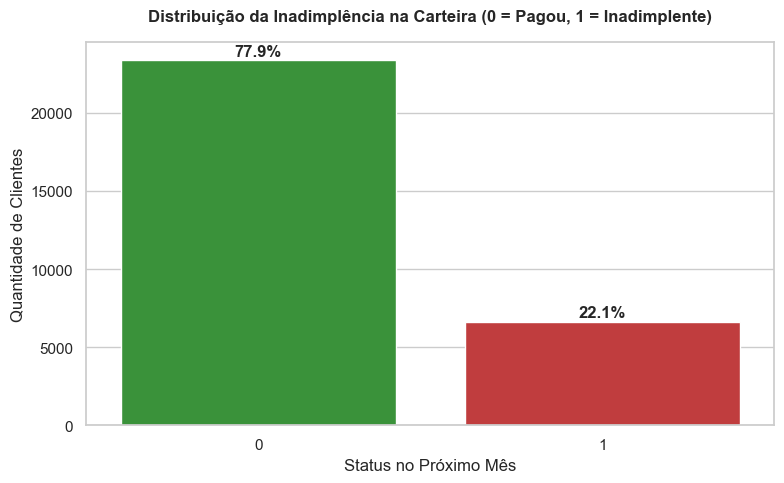

In [3]:
# ==============================================================================
# 3. ANÁLISE DA VARIÁVEL ALVO (TARGET)
# ==============================================================================
print(">>> Gerando distribuição da variável alvo...")

target_col = 'default.payment.next.month'

# 1. Plotagem do gráfico de contagem
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x=target_col, data=df, palette=['#2ca02c', '#d62728'], ax=ax)

# 2. Cosmética e anotações
ax.set_title('Distribuição da Inadimplência na Carteira (0 = Pagou, 1 = Inadimplente)', fontweight='bold', pad=15)
ax.set_ylabel('Quantidade de Clientes')
ax.set_xlabel('Status no Próximo Mês')

# 3. Cálculo e exibição dos percentuais
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y + 100), ha='center', va='bottom', fontweight='bold')

# 4. Exportação e exibição
plt.tight_layout()
plt.savefig('../assets/img/target_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Gráfico gerado e salvo com sucesso!\n")
plt.show()

# Distribuição do limite de crédito

Nesta etapa, analisamos como o banco distribui o risco financeiro (`LIMIT_BAL`). A hipótese é que limites menores possam concentrar uma densidade maior de inadimplência, refletindo clientes com perfis de risco naturalmente mais elevados ou menor capacidade de comprovação de renda.

>>> Analisando a distribuição de limites de crédito...
✅ Gráfico gerado e salvo com sucesso!



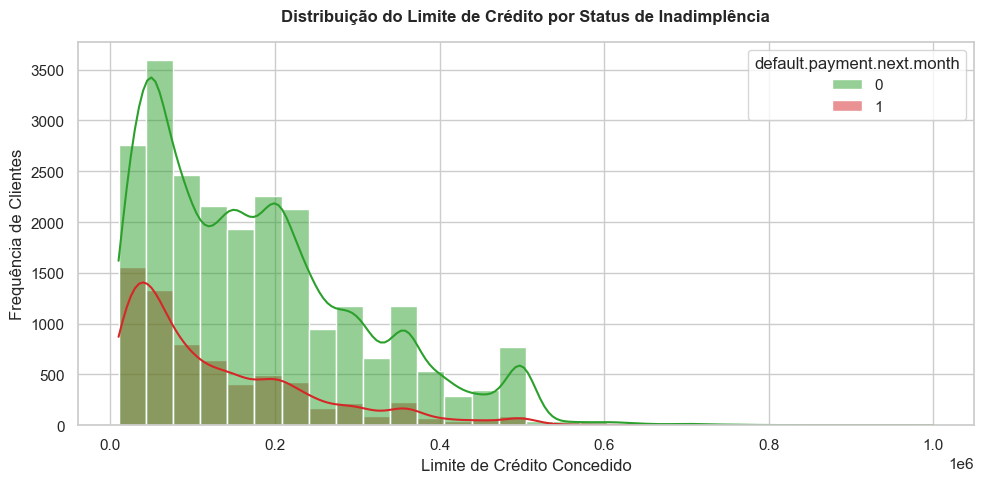

In [4]:
# ==============================================================================
# 4. DISTRIBUIÇÃO DO LIMITE DE CRÉDITO (LIMIT_BAL)
# ==============================================================================
print(">>> Analisando a distribuição de limites de crédito...")

fig, ax = plt.subplots(figsize=(10, 5))

# 1. Histograma com estimativa de densidade
sns.histplot(data=df, x='LIMIT_BAL', hue=target_col, bins=30, kde=True, palette=['#2ca02c', '#d62728'], ax=ax)

# 2. Cosmética do gráfico
ax.set_title('Distribuição do Limite de Crédito por Status de Inadimplência', fontweight='bold', pad=15)
ax.set_xlabel('Limite de Crédito Concedido')
ax.set_ylabel('Frequência de Clientes')

# 3. Exportação e exibição
plt.tight_layout()
plt.savefig('../assets/img/credit_limit_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Gráfico gerado e salvo com sucesso!\n")
plt.show()

# Impacto do comportamento de pagamento recente

A variável `PAY_0` representa o status de pagamento da fatura mais recente fechada (Setembro) em relação ao mês alvo (Outubro). 
* **Valores $\le$ 0:** Fatura paga em dia.
* **Valores $>$ 0:** Quantidade de meses de atraso daquela fatura.

>>> Mapeando o status de pagamento recente vs inadimplência futura...
✅ Gráfico gerado com sucesso!



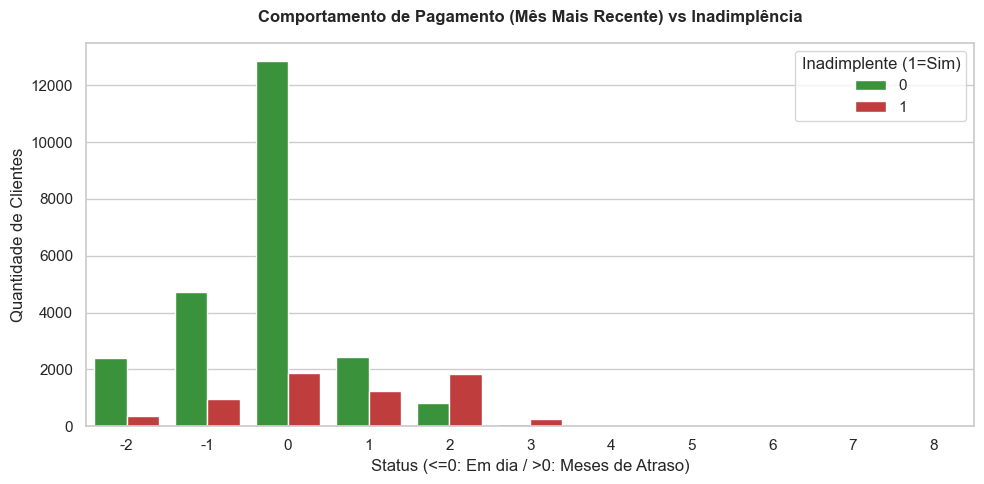

In [5]:
# ==============================================================================
# 5. IMPACTO DOS ATRASOS DE PAGAMENTO (PAY_0)
# ==============================================================================
print(">>> Mapeando o status de pagamento recente vs inadimplência futura...")

fig, ax = plt.subplots(figsize=(10, 5))

# 1. Gráfico de barras agrupadas
sns.countplot(data=df, x='PAY_0', hue=target_col, palette=['#2ca02c', '#d62728'], ax=ax)

# 2. Cosmética do gráfico
ax.set_title('Comportamento de Pagamento (Mês Mais Recente) vs Inadimplência', fontweight='bold', pad=15)
ax.set_xlabel('Status (<=0: Em dia / >0: Meses de Atraso)')
ax.set_ylabel('Quantidade de Clientes')
ax.legend(title='Inadimplente (1=Sim)', loc='upper right')

# 3. Exportação e exibição
plt.tight_layout()
plt.savefig('../assets/img/recent_payment_impact.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Gráfico gerado com sucesso!\n")
plt.show()

# Correlação de variáveis financeiras

A matriz de correlação linear ajuda a identificar redundâncias entre as variáveis (multicolinearidade). Para manter a clareza analítica, filtramos apenas as principais métricas de volume e tempo.

>>> Calculando correlações entre as principais variáveis...
✅ Matriz gerada com sucesso!



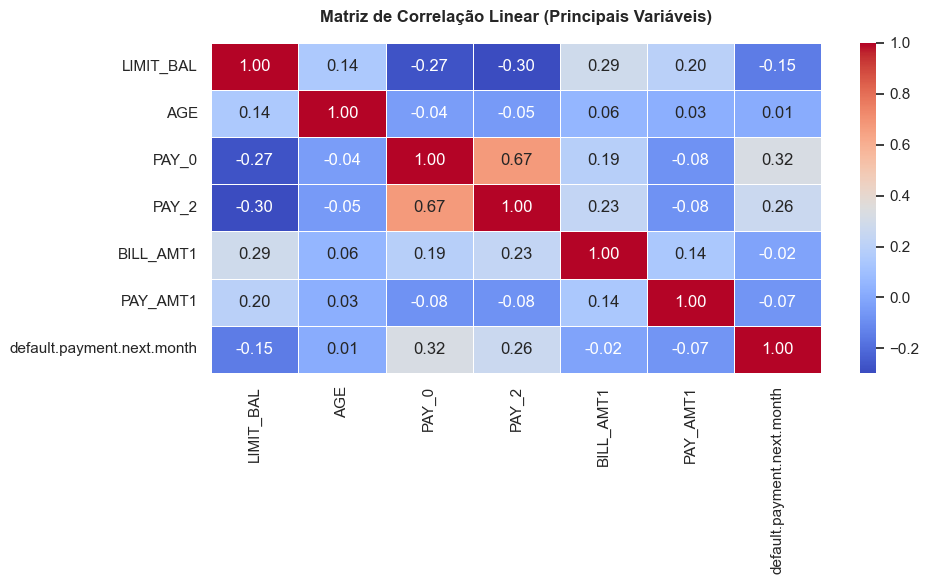

In [6]:
# ==============================================================================
# 6. MATRIZ DE CORRELAÇÃO (VISÃO DE NEGÓCIO)
# ==============================================================================
print(">>> Calculando correlações entre as principais variáveis...")

# 1. Seleção estratégica de colunas para análise
cols_to_plot = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'BILL_AMT1', 'PAY_AMT1', target_col]
corr_matrix = df[cols_to_plot].corr()

# 2. Plotagem do Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax)

# 3. Cosmética
ax.set_title('Matriz de Correlação Linear (Principais Variáveis)', fontweight='bold', pad=15)

# 4. Exportação e exibição
plt.tight_layout()
plt.savefig('../assets/img/correlation_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Matriz gerada com sucesso!\n")
plt.show()